In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/zepto-capstone/analytics

print("Current folder:")
!pwd

print("\nFiles:")
!ls -la

/content/drive/MyDrive/zepto-capstone/analytics
Current folder:
/content/drive/MyDrive/zepto-capstone/analytics

Files:
total 16
drwx------ 2 root root 4096 Sep 27 05:24 .
drwx------ 4 root root 4096 Sep 27 05:24 ..
drwx------ 2 root root 4096 Sep 27 10:24 charts
drwx------ 2 root root 4096 Sep 27 10:24 model
-rw------- 1 root root    0 Sep 27 05:25 README.md


In [3]:
import seaborn as sns
import pandas as pd

# Load Titanic dataset ONCE
df = sns.load_dataset("titanic")

# Save the raw dataset as the required offline fallback
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)
print("\nSaved file:")
!ls -lh titanic.csv

Titanic dataset loaded successfully.
Shape: (891, 15)

Saved file:
-rw------- 1 root root 56K Sep 27 12:06 titanic.csv


In [4]:
sns.load_dataset("titanic")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
print("===== DATASET INFO =====")
df.info()

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== DESCRIPTIVE STATISTICS =====")
display(df.describe(include="all"))

print("\n===== MISSING VALUES =====")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct
})

display(missing_report[missing_report["missing_count"] > 0])

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

===== DATASET SHAPE =====
(891, 15)

===== DESCRIPTIV

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== MISSING VALUES =====


,missing_count,missing_percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [6]:
# Make a copy so the original loaded DataFrame remains unchanged
df_clean = df.copy()

# 1. Drop rows with less than 5% missing values
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

# 2. Impute age because it has 5%–30% missing values
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# 3. Drop deck because 77.22% of its values are missing
df_clean = df_clean.drop(columns=["deck"])

print("Cleaning completed.")
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum().sort_values(ascending=False).head(10))

Cleaning completed.
Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [7]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned Titanic dataset saved successfully.")

Cleaned Titanic dataset saved successfully.


===== AGE OUTLIERS =====
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of age outliers: 65

===== FARE OUTLIERS =====
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of fare outliers: 114

===== FARE DISTRIBUTION =====
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Skewness conclusion: Right-skewed


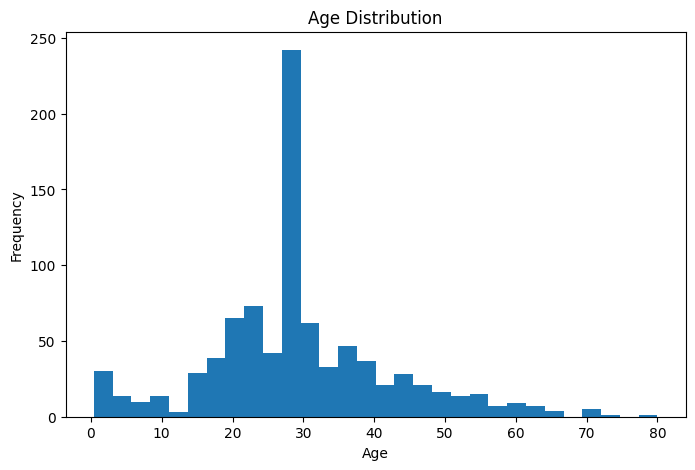

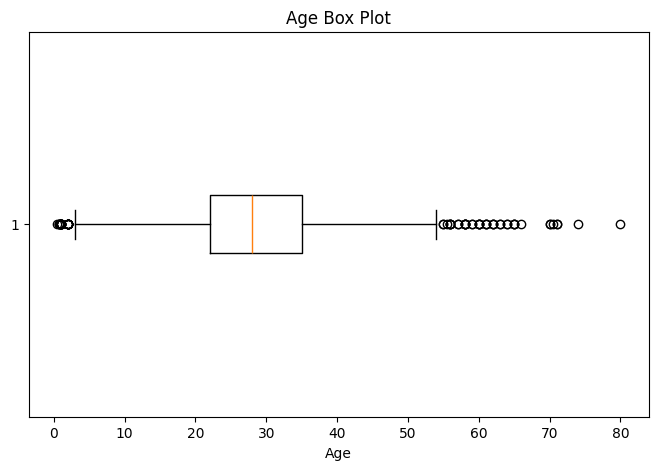

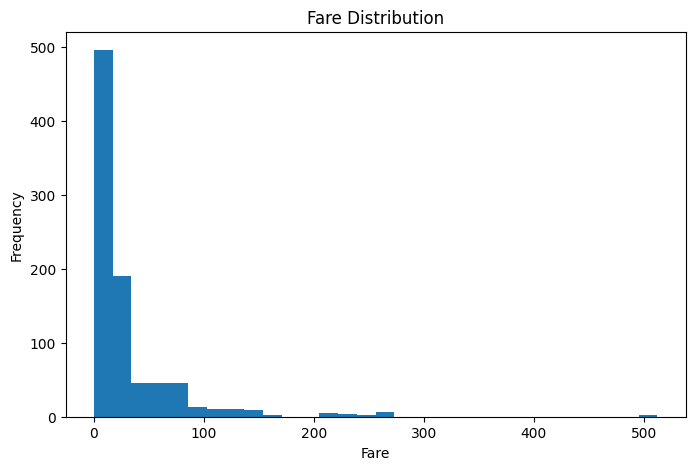

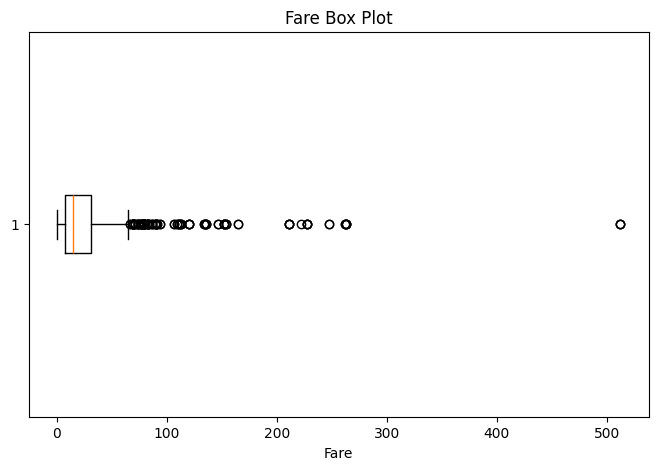

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# TASK 3 — UNIVARIATE ANALYSIS
# ==========================================

# ---------- AGE ----------
age_q1 = df_clean["age"].quantile(0.25)
age_q3 = df_clean["age"].quantile(0.75)
age_iqr = age_q3 - age_q1

age_lower = age_q1 - 1.5 * age_iqr
age_upper = age_q3 + 1.5 * age_iqr

age_outliers = df_clean[
    (df_clean["age"] < age_lower) |
    (df_clean["age"] > age_upper)
]

# ---------- FARE ----------
fare_q1 = df_clean["fare"].quantile(0.25)
fare_q3 = df_clean["fare"].quantile(0.75)
fare_iqr = fare_q3 - fare_q1

fare_lower = fare_q1 - 1.5 * fare_iqr
fare_upper = fare_q3 + 1.5 * fare_iqr

fare_outliers = df_clean[
    (df_clean["fare"] < fare_lower) |
    (df_clean["fare"] > fare_upper)
]

# ---------- FARE STATISTICS ----------
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode().iloc[0]

# Determine skewness from mean / median / mode
if fare_mean > fare_median > fare_mode:
    skew_result = "Right-skewed"
elif fare_mean < fare_median < fare_mode:
    skew_result = "Left-skewed"
else:
    skew_result = "Not clearly determined by mean/median/mode ordering"

# ==========================================
# PRINT RESULTS
# ==========================================

print("===== AGE OUTLIERS =====")
print("Q1:", age_q1)
print("Q3:", age_q3)
print("IQR:", age_iqr)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)
print("Number of age outliers:", len(age_outliers))

print("\n===== FARE OUTLIERS =====")
print("Q1:", fare_q1)
print("Q3:", fare_q3)
print("IQR:", fare_iqr)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)
print("Number of fare outliers:", len(fare_outliers))

print("\n===== FARE DISTRIBUTION =====")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)
print("Skewness conclusion:", skew_result)

# ==========================================
# PLOTS
# ==========================================

plt.figure(figsize=(8, 5))
plt.hist(df_clean["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["age"], vert=False)
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_clean["fare"], bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["fare"], vert=False)
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

===== SURVIVAL RATE BY SEX =====
Male survival rate:   18.89%
Female survival rate: 74.04%

===== SURVIVAL RATE BY PCLASS =====
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%

===== SURVIVAL RATE BY SEX + PCLASS =====


,sex,pclass,survival_rate
0,female,1,96.739130
1,female,2,92.105263
2,female,3,50.000000
3,male,1,36.885246
4,male,2,15.740741
5,male,3,13.544669



===== CORRELATION MATRIX =====


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


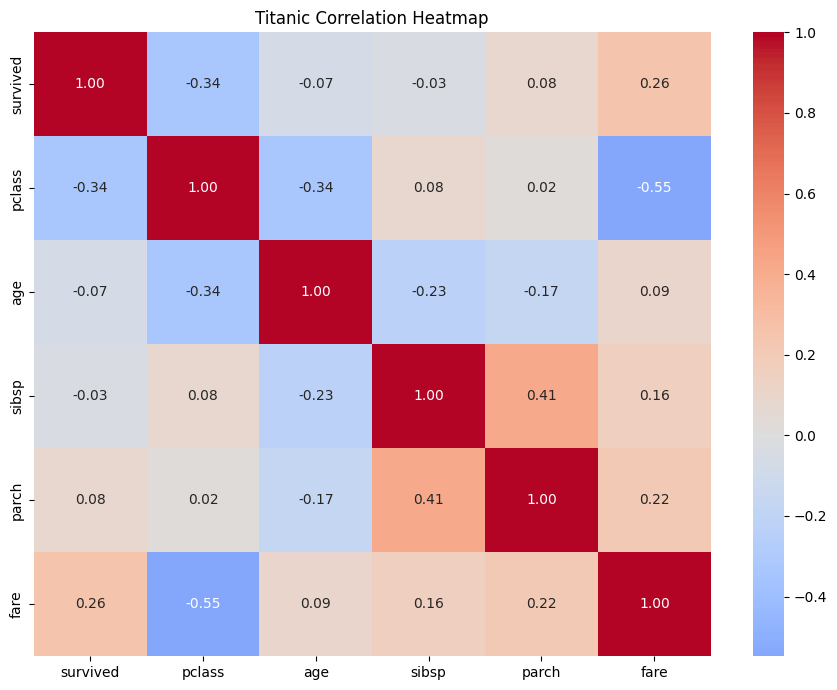


===== TWO STRONGEST CORRELATIONS =====
pclass ↔ fare: correlation = -0.5482
sibsp ↔ parch: correlation = 0.4145


In [9]:
# ==========================================
# TASK 4 — BIVARIATE ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Survival rate by SEX
# ------------------------------------------

male_survival = df_clean[df_clean["sex"] == "male"]["survived"].mean()
female_survival = df_clean[df_clean["sex"] == "female"]["survived"].mean()

print("===== SURVIVAL RATE BY SEX =====")
print(f"Male survival rate:   {male_survival:.2%}")
print(f"Female survival rate: {female_survival:.2%}")


# ------------------------------------------
# 2. Survival rate by PCLASS
# ------------------------------------------

print("\n===== SURVIVAL RATE BY PCLASS =====")

for pclass in sorted(df_clean["pclass"].unique()):
    rate = df_clean[df_clean["pclass"] == pclass]["survived"].mean()
    print(f"Class {pclass}: {rate:.2%}")


# ------------------------------------------
# 3. Survival rate by SEX + PCLASS
# ------------------------------------------

print("\n===== SURVIVAL RATE BY SEX + PCLASS =====")

sex_pclass_survival = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

sex_pclass_survival["survival_rate"] = (
    sex_pclass_survival["survived"] * 100
)

display(
    sex_pclass_survival[
        ["sex", "pclass", "survival_rate"]
    ]
)


# ------------------------------------------
# 4. CORRELATION MATRIX
# ------------------------------------------

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[correlation_columns].corr()

print("\n===== CORRELATION MATRIX =====")
display(corr_matrix)


# ------------------------------------------
# 5. CORRELATION HEATMAP
# ------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 6. FIND TWO STRONGEST CORRELATIONS
# ------------------------------------------

corr_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        col1 = correlation_columns[i]
        col2 = correlation_columns[j]
        value = corr_matrix.loc[col1, col2]

        corr_pairs.append(
            (col1, col2, value, abs(value))
        )

strongest_pairs = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)[:2]

print("\n===== TWO STRONGEST CORRELATIONS =====")

for col1, col2, value, absolute_value in strongest_pairs:
    print(
        f"{col1} ↔ {col2}: "
        f"correlation = {value:.4f}"
    )

In [10]:
# ==========================================
# BOOLEAN MASKING CHECK
# ==========================================

print("===== BOOLEAN MASKING: SEX =====")

female_mask = df_clean["sex"] == "female"
male_mask = df_clean["sex"] == "male"

print("Female survival rate:",
      df_clean.loc[female_mask, "survived"].mean())

print("Male survival rate:",
      df_clean.loc[male_mask, "survived"].mean())


print("\n===== BOOLEAN MASKING: PCLASS =====")

class1_mask = df_clean["pclass"] == 1
class2_mask = df_clean["pclass"] == 2
class3_mask = df_clean["pclass"] == 3

print("Class 1 survival rate:",
      df_clean.loc[class1_mask, "survived"].mean())

print("Class 2 survival rate:",
      df_clean.loc[class2_mask, "survived"].mean())

print("Class 3 survival rate:",
      df_clean.loc[class3_mask, "survived"].mean())


print("\n===== BOOLEAN MASKING: SEX + PCLASS =====")

female_class1 = (df_clean["sex"] == "female") & (df_clean["pclass"] == 1)
female_class2 = (df_clean["sex"] == "female") & (df_clean["pclass"] == 2)
female_class3 = (df_clean["sex"] == "female") & (df_clean["pclass"] == 3)

male_class1 = (df_clean["sex"] == "male") & (df_clean["pclass"] == 1)
male_class2 = (df_clean["sex"] == "male") & (df_clean["pclass"] == 2)
male_class3 = (df_clean["sex"] == "male") & (df_clean["pclass"] == 3)

masks = {
    "Female + Class 1": female_class1,
    "Female + Class 2": female_class2,
    "Female + Class 3": female_class3,
    "Male + Class 1": male_class1,
    "Male + Class 2": male_class2,
    "Male + Class 3": male_class3
}

for name, mask in masks.items():
    rate = df_clean.loc[mask, "survived"].mean()
    print(f"{name}: {rate:.2%}")

===== BOOLEAN MASKING: SEX =====
Female survival rate: 0.7403846153846154
Male survival rate: 0.18890814558058924

===== BOOLEAN MASKING: PCLASS =====
Class 1 survival rate: 0.6261682242990654
Class 2 survival rate: 0.47282608695652173
Class 3 survival rate: 0.24236252545824846

===== BOOLEAN MASKING: SEX + PCLASS =====
Female + Class 1: 96.74%
Female + Class 2: 92.11%
Female + Class 3: 50.00%
Male + Class 1: 36.89%
Male + Class 2: 15.74%
Male + Class 3: 13.54%


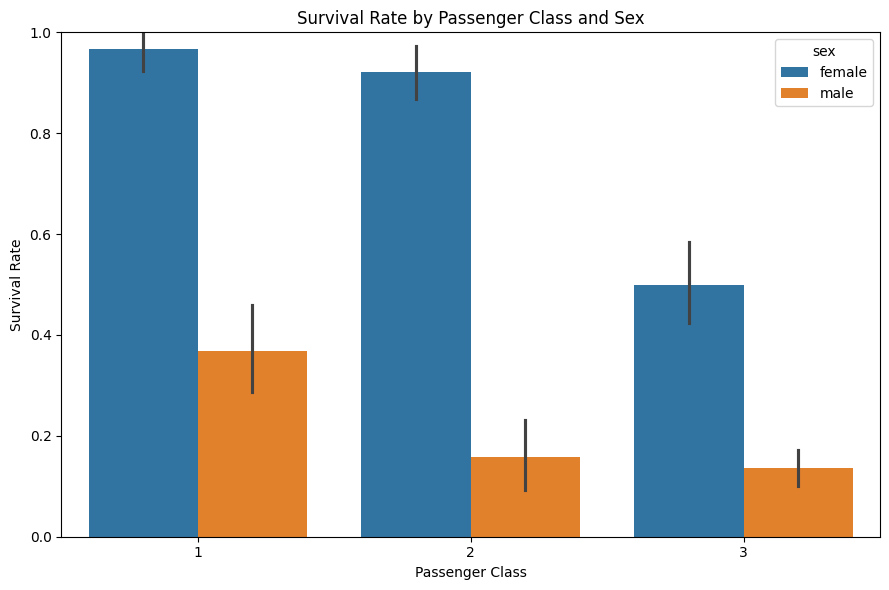

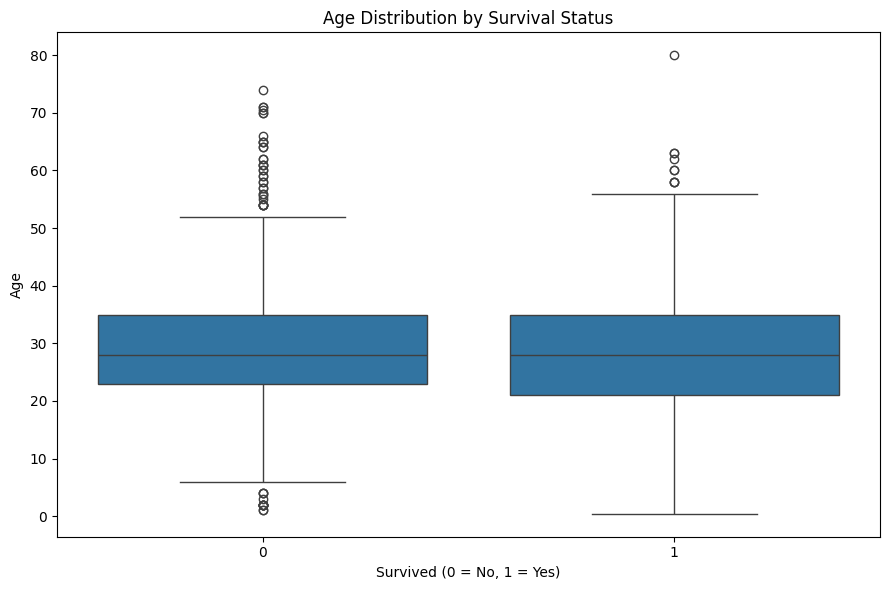

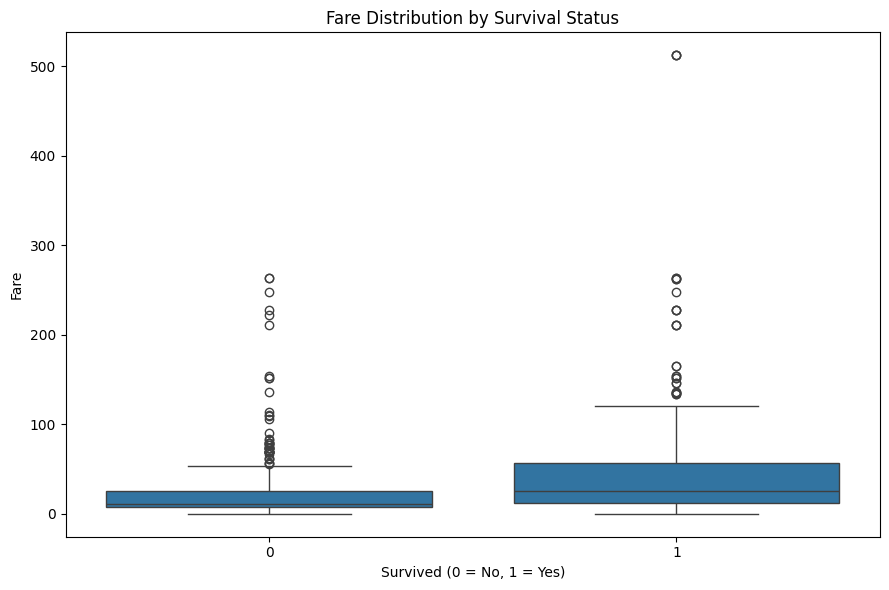

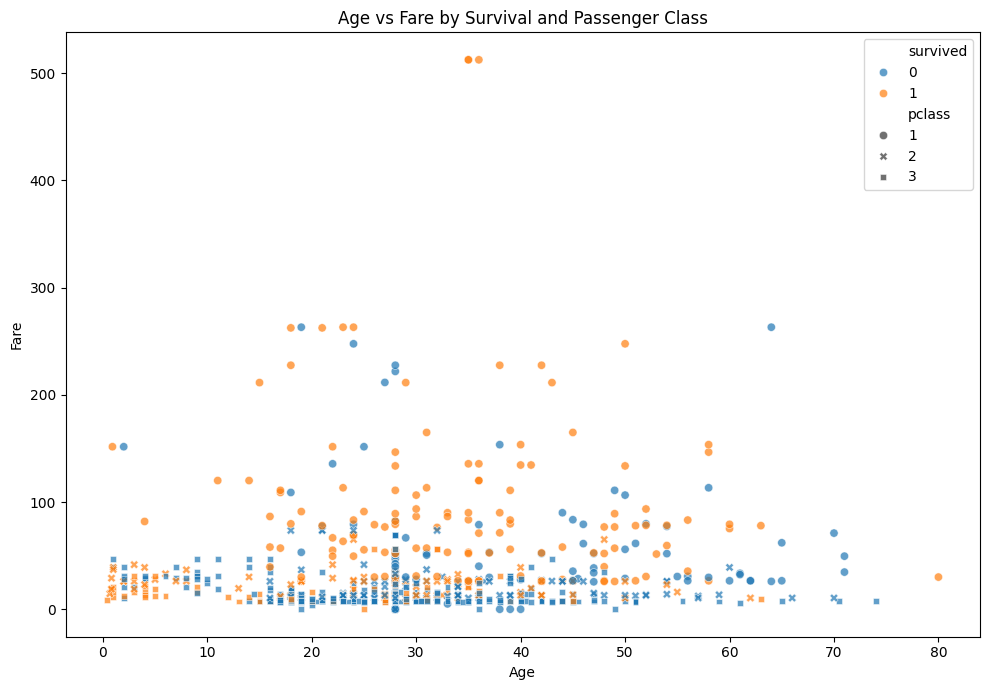

In [11]:
# ==========================================
# TASK 5 — MULTIVARIATE DATA STORY
# ==========================================

# ------------------------------------------
# CHART 1 — Survival by Sex and Class
# ------------------------------------------

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("charts/survival_by_sex_class.png", dpi=150)
plt.show()


# ------------------------------------------
# CHART 2 — Age Distribution by Survival
# ------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()

plt.savefig("charts/age_by_survival.png", dpi=150)
plt.show()


# ------------------------------------------
# CHART 3 — Fare Distribution by Survival
# ------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.tight_layout()

plt.savefig("charts/fare_by_survival.png", dpi=150)
plt.show()


# ------------------------------------------
# CHART 4 — Age vs Fare
# ------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Passenger Class")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()

plt.savefig("charts/age_fare_survival.png", dpi=150)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# TASK 6 — STANDARDIZATION CHECK
# ==========================================

scaler = StandardScaler()

# Standardize age and fare
standardized = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

df_standardized = df_clean.copy()

df_standardized["age_standardized"] = standardized[:, 0]
df_standardized["fare_standardized"] = standardized[:, 1]

# ------------------------------------------
# BEFORE STANDARDIZATION
# ------------------------------------------

print("===== BEFORE STANDARDIZATION =====")

print("\nAge:")
print("Mean:", df_clean["age"].mean())
print("Std :", df_clean["age"].std())

print("\nFare:")
print("Mean:", df_clean["fare"].mean())
print("Std :", df_clean["fare"].std())


# ------------------------------------------
# AFTER STANDARDIZATION
# ------------------------------------------

print("\n===== AFTER STANDARDIZATION =====")

print("\nAge standardized:")
print("Mean:", df_standardized["age_standardized"].mean())
print("Std :", df_standardized["age_standardized"].std())

print("\nFare standardized:")
print("Mean:", df_standardized["fare_standardized"].mean())
print("Std :", df_standardized["fare_standardized"].std())


# ------------------------------------------
# SAMPLE COMPARISON
# ------------------------------------------

print("\n===== SAMPLE =====")

display(
    df_standardized[
        [
            "age",
            "age_standardized",
            "fare",
            "fare_standardized"
        ]
    ].head(10)
)

===== BEFORE STANDARDIZATION =====

Age:
Mean: 29.315151856017994
Std : 12.984932293690774

Fare:
Mean: 32.09668087739032
Std : 49.69750431670801

===== AFTER STANDARDIZATION =====

Age standardized:
Mean: 2.717486278497571e-16
Std : 1.000562904632249

Fare standardized:
Mean: 1.3987061727561027e-16
Std : 1.0005629046322495

===== SAMPLE =====


,age,age_standardized,fare,fare_standardized
0,22.0,-0.563674,7.2500,-0.500240
1,38.0,0.669217,71.2833,0.788947
2,26.0,-0.255451,7.9250,-0.486650
3,35.0,0.438050,53.1000,0.422861
4,35.0,0.438050,8.0500,-0.484133
5,28.0,-0.101340,8.4583,-0.475913
6,54.0,1.902108,51.8625,0.397946
7,2.0,-2.104788,21.0750,-0.221900
8,27.0,-0.178396,11.1333,-0.422057
9,14.0,-1.180120,30.0708,-0.040787
